# Sprint 11

## Create environment file to save passwords

Create a .env doc and add it to .gitignore. In this case, I wrote the following variables:  
DB_HOST=localhost  
DB_USER=root  
DB_PASSWORD=your_password  
DB_NAME=database_name  

In [ ]:
# pip install python-dotenv

To check if it works:  

from dotenv import load_dotenv  
import os

**load_dotenv()**

print(os.getenv("DB_HOST"))

## How to Connect to MySQL Database in Python  
**MySQL connector**  
https://pynative.com/python-mysql-database-connection/

1. Install MySQL connector module  
Use the pip command to [install MySQL connector Python](https://pynative.com/install-mysql-connector-python/).

In [ ]:
#pip install mysql-connector-python

2. Import MySQL connector module

In [1]:
import mysql.connector
# you can use this module’s methods to communicate with the MySQL database

3. Use the connect() method  
Use the connect() method of the MySQL Connector class with the required arguments to connect MySQL. It would return a MySQLConnection object if the connection established successfully

4. Use the cursor() method  
Use the cursor() method of a MySQLConnection object to create a cursor object to perform various SQL operations.

5. Use the execute() method  
The execute() methods run the SQL query and return the result.

6. Extract result using fetchall()  
Use cursor.fetchall() or fetchone() or fetchmany() to read query result.

7. Close cursor and connection objects  
use cursor.clsoe() and connection.clsoe() method to close open connections after your work completes

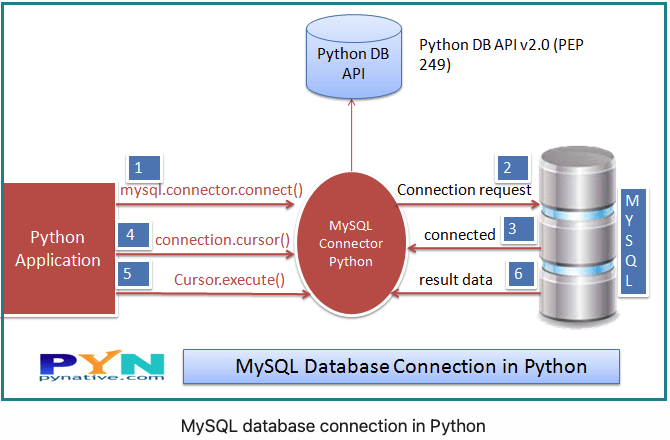

🧠 Resum mètodes

- connect() → obrir connexió
- cursor() → preparar executor
- execute() → enviar query
- fetch...() → obtenir resultats
- close() → tancar-ho tot

*fetch*:  
👉 Recuperen els resultats de la query
- fetchall() → tot
- fetchone() → una fila
- fetchmany(n) → n files

### **Check connection**

In [20]:
import mysql.connector
from mysql.connector import Error

from dotenv import load_dotenv  
import os

load_dotenv()

try:
    connection = mysql.connector.connect(host=os.getenv("DB_HOST"),
                                         database='transactions',
                                         user=os.getenv('DB_USER'),
                                         password=os.getenv('DB_PASSWORD'))
    if connection.is_connected():
        db_Info = connection.get_server_info()
        print("Connected to MySQL Server version ", db_Info)
        cursor = connection.cursor()
        cursor.execute("select database();")
        record = cursor.fetchone()
        print("You're connected to database: ", record)

except Error as e:
    print("Error while connecting to MySQL", e)
finally:
    if connection.is_connected():
        cursor.close()
        connection.close()
        print("MySQL connection is closed")


Connected to MySQL Server version  8.0.44
You're connected to database:  ('transactions',)
MySQL connection is closed


/var/folders/z0/sx07zxxs0419_1m36l2hr_xr0000gp/T/ipykernel_5829/4122560054.py:15: DeprecationWarning: Call to deprecated function get_server_info. Reason: 
    The property counterpart 'server_info' should be used instead.

  db_Info = connection.get_server_info()


### **Complete workflow**:  

```
import mysql.connector
from dotenv import load_dotenv
import os

load_dotenv()

conn = mysql.connector.connect(
    host=os.getenv("DB_HOST"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    database=os.getenv("DB_NAME")
)

cursor = conn.cursor()

cursor.execute("SELECT * FROM users")

results = cursor.fetchall()

for row in results:
    print(row)

cursor.close()
conn.close()
```